# Understanding Attention Mechanisms in Transformers
This notebook walks through the fundamentals of attention mechanisms, gradually building up to multi-head self-attention and full Transformer models using pretrained weights. We'll visualize both toy and real attention maps.

In [1]:
# imports
import warnings
warnings.filterwarnings('ignore')
import torch
import numpy as np
import torch.nn.functional as F
import matplotlib.pyplot as plt
from transformers import AutoTokenizer, AutoModel
from transformers import AutoModelForSeq2SeqLM, AutoTokenizer
import warnings
warnings.simplefilter("ignore", FutureWarning)

torch.manual_seed(0)

## 1. Basic Dot-Product Attention (with manual example)
This section introduces dot-product attention using simple vectors for easy understanding.

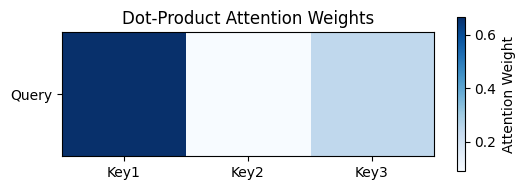

In [2]:
# Define simple query, key, and value vectors
query = torch.tensor([[1.0, 0.0, 1.0, 0.0]])   # (1, 4)
keys = torch.tensor([[1.0, 0.0, 1.0, 0.0],
                     [0.0, 1.0, 0.0, 1.0],
                     [1.0, 1.0, 0.0, 0.0]])    # (3, 4)
values = torch.tensor([[1.0, 2.0],
                       [3.0, 4.0],
                       [5.0, 6.0]])            # (3, 2)

# Compute attention scores (dot product between query and each key)
scores = torch.matmul(query, keys.T)

# Apply softmax to get attention weights
attention_weights = F.softmax(scores, dim=-1)

# Weighted sum of values
output = torch.matmul(attention_weights, values)

# Plotting the attention weights
plt.figure(figsize=(6, 2))
plt.imshow(attention_weights.detach().numpy(), cmap='Blues')
plt.xticks([0, 1, 2], ['Key1', 'Key2', 'Key3'])
plt.yticks([0], ['Query'])
plt.colorbar(label='Attention Weight')
plt.title('Dot-Product Attention Weights')
plt.show()

In [3]:
scores

tensor([[2., 0., 1.]])

In [4]:
attention_weights

tensor([[0.6652, 0.0900, 0.2447]])

In [5]:
output

tensor([[2.1590, 3.1590]])

This heatmap illustrates the attention weights between a single **query** vector and multiple **key** vectors using dot-product attention.

- Each attention score is computed as the dot product between the query and a key, then normalized via softmax.
- The resulting weights determine how much focus the query places on each key.
- In this example, **Key1** is identical to the query, so it receives the highest attention weight.
- The attention weights are used to compute a weighted sum of the **value** vectors, producing the final output.

The heatmap shows this distribution: brighter values indicate higher attention, revealing where the model "looks" to generate output.

## 2. Self-Attention Across a Sequence
Now we move from simple attention to self-attention, where every token attends to every other token in a sequence.

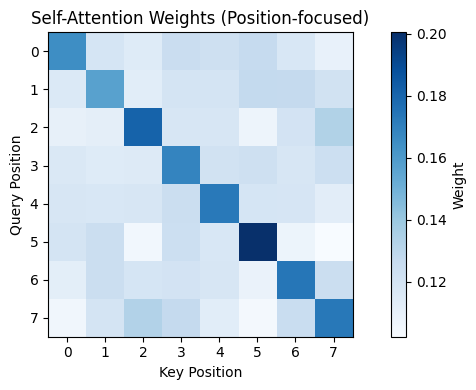

In [6]:
# Create a sequence of token embeddings with a strong position signal
seq_len = 8
embed_dim = 8

# Each token is just an identity matrix row + slight noise to simulate position encodings
tokens = torch.eye(seq_len, embed_dim).unsqueeze(0)  # shape: (1, seq_len, embed_dim)
tokens += 0.1 * torch.randn_like(tokens)  # add some noise for realism

# Self-attention computation
query, key, value = tokens, tokens, tokens


scores = torch.matmul(query, key.transpose(-2, -1)) / embed_dim**0.5






weights = F.softmax(scores, dim=-1)
output = torch.matmul(weights, value)

# Plot the attention weights heatmap
plt.figure(figsize=(8, 4))
plt.imshow(weights[0].detach().numpy(), cmap='Blues')
plt.title("Self-Attention Weights (Position-focused)")
plt.xlabel("Key Position")
plt.ylabel("Query Position")
plt.colorbar(label='Weight')
plt.xticks(np.arange(seq_len))
plt.yticks(np.arange(seq_len))
plt.tight_layout()
plt.show()

In [7]:
value

tensor([[[ 0.8874, -0.1152, -0.0251, -0.0434,  0.0849,  0.0692, -0.0316,
          -0.2115],
         [ 0.0322,  0.8737,  0.0350,  0.0308,  0.0120,  0.1238,  0.1117,
          -0.0247],
         [-0.1353, -0.1696,  1.0567,  0.0794,  0.0599, -0.1555, -0.0341,
           0.1853],
         [ 0.0750, -0.0585, -0.0173,  1.0183,  0.1389,  0.1586,  0.0946,
          -0.0844],
         [-0.0614,  0.0032, -0.0493,  0.0248,  1.0440,  0.0112,  0.0641,
           0.0441],
         [-0.0102,  0.0792, -0.0290,  0.0053,  0.0523,  1.2302, -0.1469,
          -0.1587],
         [-0.0673,  0.0873,  0.1055,  0.0178, -0.0230, -0.0392,  1.0543,
          -0.0395],
         [-0.0446,  0.0744,  0.1521,  0.3411, -0.1531, -0.1234,  0.1820,
           0.9448]]])

This heatmap visualizes self-attention weights across a sequence of tokens with strong positional signals.

- Each token embedding is initialized to resemble a position vector (identity matrix row), with slight noise to mimic real embeddings.
- The attention scores are computed between all token pairs and normalized with softmax.
- Because the embeddings encode position, tokens tend to attend more strongly to themselves and nearby positions.
- This produces a clear **diagonal band** in the heatmap, a common pattern in early Transformer layers where attention is locally focused.

Brighter values indicate stronger attention, typically centered around each token's own position.

## 3. Attention Maps from a Pretrained Transformer
Let's load a pretrained BERT model and visualize the attention weights on an input sentence.

## 🧠 Zusammenfassung: BERT-Aufmerksamkeitsanalyse

Der vorangestellte Code führt eine Analyse der **Aufmerksamkeitsgewichte (Attention Weights)** des vortrainierten Modells `bert-base-uncased` für einen spezifischen Satz durch.

### 1. 🎯 Ziel der Analyse: Mechanismen statt Endergebnis

BERT wird trainiert, um **kontextualisierte Embeddings** (die finalen Vektoren für nachgeschaltete Aufgaben) zu erzeugen.

* **Ihr Code extrahiert NICHT die Embeddings**, sondern die **Aufmerksamkeitsgewichte (`outputs.attentions`)**.
* **Zweck:** Die Aufmerksamkeitsgewichte sind die **internen Messungen** (die "Logik" oder der "Fokus"), die zeigen, **wie** das Modell die Repräsentationen der Wörter mischt, um die Kontextualisierung zu erreichen. Dies dient der **Erklärbarkeit (Interpretability)**.

### 2. 🧱 Die Architektur: 12 Schichten

BERT-Base besteht aus **12 gestapelten Transformer-Encodern** (Schichten).

* Jede Schicht führt eine weitere Runde **kontextueller Verarbeitung** durch.
* **Niedrige Schichten (1-4)**: Konzentrieren sich auf lokale Syntax und einfache Beziehungen.
* **Hohe Schichten (9-12)**: Konzentrieren sich auf die globale Satzbedeutung und abstrakte Semantik.

### 3. ⚙️ Die Extraktion und Berechnung

Die Aufmerksamkeitsgewichte werden Schicht für Schicht und Kopf für Kopf berechnet.

* `attentions`: Enthält eine Liste von 12 Tensoren (einer pro Schicht), jeweils der Form `(1, 12 Heads, L, L)`, wobei $L$ die Sequenzlänge (Anzahl der Tokens) ist.
* `attn_avg = attn_tensor.mean(dim=(0, 1))`: Die Gewichte werden über **alle 12 Schichten** und **alle 12 Attention Heads** gemittelt. Dies erzeugt eine einzige, aggregierte Aufmerksamkeitsmatrix.

### 4. 📈 Die Aufmerksamkeitsmatrix

Die resultierende Matrix ist eine **$L_{neu} \times L_{neu}$** Matrix, wobei $L_{neu}$ die Anzahl der **Nicht-Spezial-Tokens** (Ihre eigentlichen Wörter) ist.

* **Zellenwert $(i, j)$**: Gibt an, wie stark das Wort in **Zeile $i$** seine Aufmerksamkeit auf das Wort in **Spalte $j$** lenkt (im Durchschnitt des gesamten Modells).
* **Interpretation**: Hohe Werte (dunkle Farbe in der Heatmap) zeigen eine starke Beziehung und Relevanz zwischen diesen beiden Wörtern im Kontext des Satzes an.

In [7]:
# Load BERT tokenizer and model
tokenizer = AutoTokenizer.from_pretrained("bert-base-uncased")
model = AutoModel.from_pretrained("bert-base-uncased", output_attentions=True)

# Input sentence
#sentence = "The quick brown fox jumps over the lazy dog"
sentence = "My dog loves good belly rubs"
inputs = tokenizer(sentence, return_tensors="pt")

# Forward pass with attentions
with torch.no_grad():
    outputs = model(**inputs)

attentions = outputs.attentions  # List of tensors: 12 layers, each (batch, heads, seq, seq)
tokens = tokenizer.convert_ids_to_tokens(inputs["input_ids"][0])

# Identify non-special tokens
special_ids = set(tokenizer.all_special_ids)
non_special_indices = [i for i, token_id in enumerate(inputs["input_ids"][0]) if token_id.item() not in special_ids]
filtered_tokens = [tokens[i] for i in non_special_indices]

# Stack and average attention: (layers, heads, seq, seq)
attn_tensor = torch.stack(attentions)[:, 0]  # remove batch dim
attn_avg = attn_tensor.mean(dim=(0, 1))  # shape: (seq, seq)

# Filter attention matrix for non-special tokens
attn_filtered = attn_avg[non_special_indices][:, non_special_indices].detach().numpy()

# Plot heatmap
plt.figure(figsize=(8, 4))
plt.imshow(attn_filtered, cmap='Blues')
plt.xticks(range(len(filtered_tokens)), filtered_tokens, rotation=90)
plt.yticks(range(len(filtered_tokens)), filtered_tokens)
plt.title("BERT Attention Averaged (No Special Tokens)")
plt.colorbar(label="Attention Weight")
plt.tight_layout()
plt.show()

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/466k [00:00<?, ?B/s]

ImportError: cannot import name 'ExecutableLocation' from 'tensorflow.python.distribute.cluster_resolver.kubernetes_cluster_resolver' (c:\Users\User\AppData\Local\Programs\Python\Python311\Lib\site-packages\tensorflow\python\distribute\cluster_resolver\kubernetes_cluster_resolver.py)

This heatmap shows the self-attention weights from a pretrained BERT model for the sentence:

> *"The quick brown fox jumps over the lazy dog"*

- The visualization displays **average attention over all layers and heads**.
- Each token attends to every other token, and the weights reflect how much focus is placed on each.
- The **rows** represent query tokens, while the **columns** represent key tokens.
- Bright spots indicate strong attention, revealing which words influence each other most during encoding.
- Since it is self-attention, the attention weights are concentrated more towards the diagonal.

This type of visualization helps interpret how BERT captures relationships between words in context.

## 4. Attention Maps on Translation (Encoder-Decoder Attention)
In encoder-decoder models like T5, the decoder generates output by attending to the encoder's representations.
Here we:
- Translate a sentence using `t5-small`
- Extract cross-attention weights (decoder attending to encoder)
- Visualize how each translated token relates to input tokens

Translation: Die Schlüssel unter der Mat fehlte.


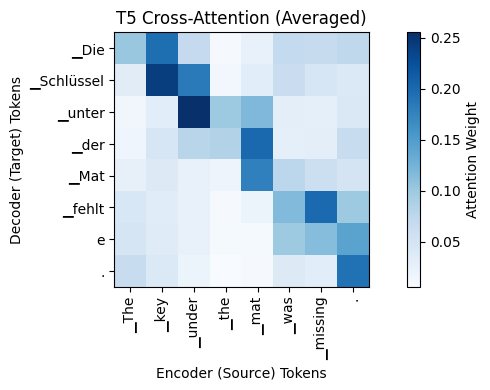

In [11]:
# Load T5 model and tokenizer
model_name = "t5-small"
tokenizer = AutoTokenizer.from_pretrained(model_name)
model = AutoModelForSeq2SeqLM.from_pretrained(model_name)

# Input sentence
src_text = "The key under the mat was missing."
inputs = tokenizer(src_text, return_tensors="pt")

# Generate translation
with torch.no_grad():
    outputs = model.generate(
        **inputs,
        output_attentions=True,
        return_dict_in_generate=True,
        output_hidden_states=False
    )

# Decode and print translation
translation = tokenizer.decode(outputs.sequences[0], skip_special_tokens=True)
print("Translation:", translation)

# Get full cross-attention from decoder
decoder_outputs = model(
    **inputs,
    decoder_input_ids=outputs.sequences,
    output_attentions=True
)
cross_attentions = decoder_outputs.cross_attentions  # List of (layers, batch, heads, tgt, src)

# Stack and average: shape (layers, heads, tgt, src) → avg (tgt, src)
attn_tensor = torch.stack(cross_attentions)[:, 0]  # remove batch dim
attn_avg = attn_tensor.mean(dim=(0, 1))  # shape: (tgt_len, src_len)

# Get token labels
src_ids = inputs["input_ids"][0]
tgt_ids = outputs.sequences[0]
src_tokens = tokenizer.convert_ids_to_tokens(src_ids)
tgt_tokens = tokenizer.convert_ids_to_tokens(tgt_ids)

# Filter out special tokens (like <pad>, </s>, etc.)
special_ids = set(tokenizer.all_special_ids)
src_keep = [i for i, id_ in enumerate(src_ids) if id_.item() not in special_ids]
tgt_keep = [i for i, id_ in enumerate(tgt_ids) if id_.item() not in special_ids]
src_tokens_filtered = [src_tokens[i] for i in src_keep]
tgt_tokens_filtered = [tgt_tokens[i] for i in tgt_keep]

# Filter attention matrix
attn_filtered = attn_avg[tgt_keep][:, src_keep].detach().numpy()

# Plot cross-attention heatmap
plt.figure(figsize=(8, 4))
plt.imshow(attn_filtered, cmap='Blues')
plt.xticks(range(len(src_tokens_filtered)), src_tokens_filtered, rotation=90)
plt.yticks(range(len(tgt_tokens_filtered)), tgt_tokens_filtered)
plt.title("T5 Cross-Attention (Averaged)")
plt.xlabel("Encoder (Source) Tokens")
plt.ylabel("Decoder (Target) Tokens")
plt.colorbar(label='Attention Weight')
plt.tight_layout()
plt.show()

This heatmap visualizes the **cross-attention weights** from a T5 model during translation.

- Input sentence: *"The key under the mat was missing."*
- The decoder generates a translation by attending to the encoder's output at each step.
- The **rows** represent decoder (target) tokens, and the **columns** represent encoder (source) tokens.
- The heatmap shows **average attention over all layers and heads**, each target token focuses on relevant parts of the input.
- Brighter cells indicate stronger attention from a target token to a source token.

This reveals how the model aligns source and target words, reflecting learned translation patterns.